# 02 — Modélisation comparative

Notebook de traçabilité : reprend les résultats du pipeline `src.models` pour exposer la comparaison des 4 modèles, le tableau des stratégies de déséquilibre et les courbes du modèle gagnant. Le notebook ne refit aucun modèle (lecture seule des CSV produits par le pipeline).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import json
import matplotlib.pyplot as plt
from IPython.display import Image

## 1. Stratégies de déséquilibre (LogReg + seuil tuné)

In [2]:
imbalance = pd.read_csv('../reports/imbalance_comparison.csv')
imbalance.round(3)

,strategy,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold
0,baseline,0.792,0.238,0.471,0.316,0.726,0.239,1489,307,108,96,0.15
1,class_weight,0.853,0.304,0.343,0.323,0.729,0.243,1636,160,134,70,0.70
2,smote,0.833,0.268,0.368,0.310,0.717,0.234,1591,205,129,75,0.70
3,rus,0.811,0.244,0.407,0.305,0.721,0.231,1539,257,121,83,0.65


La stratégie `class_weight='balanced'` arrive en tête sur F1. SMOTE et RUS sont quasi équivalents mais légèrement en retrait. La baseline sans rééquilibrage ne capture quasiment aucun churner — l'accuracy ~ 90 % masque un Recall < 5 %.

## 2. Cross-validation 5-fold sur le train

In [3]:
cv = pd.read_csv('../reports/cv_scores.csv')
cv.round(3)

,model,cv_f1_mean,cv_f1_std,cv_pr_auc_mean,cv_pr_auc_std
0,logreg,0.301,0.012,0.238,0.013
1,random_forest,0.281,0.023,0.279,0.018
2,xgboost,0.115,0.016,0.272,0.010
3,mlp,0.023,0.016,0.228,0.020


## 3. Tableau comparatif final (test set hold-out, seuil tuné)

In [4]:
final = pd.read_csv('../reports/model_comparison.csv')
cols = ['model','f1','recall','precision','pr_auc','roc_auc','accuracy','threshold','train_time_s']
final[cols].round(3)

,model,f1,recall,precision,pr_auc,roc_auc,accuracy,threshold,train_time_s
0,logreg,0.323,0.343,0.304,0.243,0.729,0.853,0.70,0.018
1,random_forest,0.407,0.789,0.274,0.303,0.807,0.765,0.35,31.825
2,xgboost,0.384,0.760,0.257,0.315,0.805,0.751,0.15,5.471
3,mlp,0.287,0.348,0.244,0.235,0.705,0.824,0.15,0.505


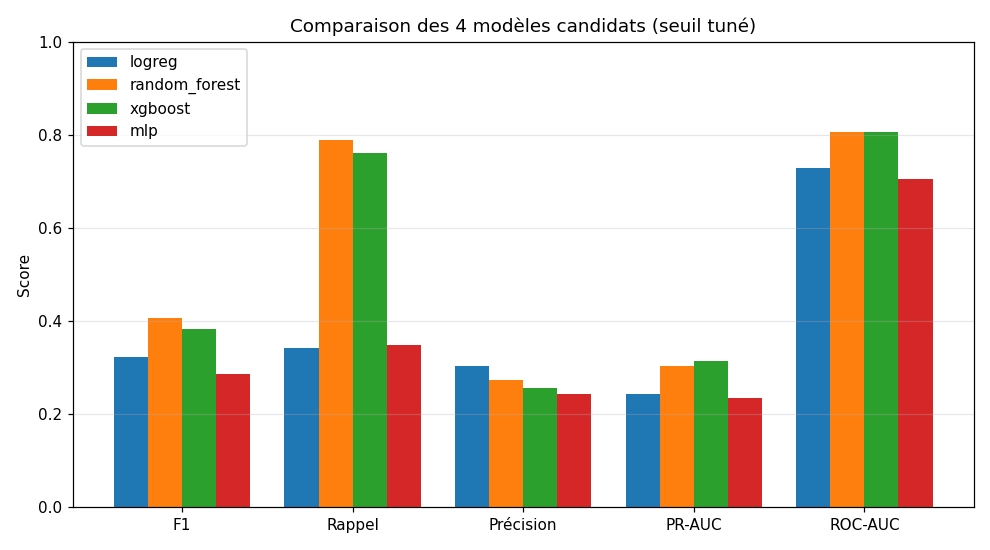

In [5]:
Image(filename='../reports/figures/model_comparison.png')

## 4. Modèle gagnant — métadonnées sérialisées

In [6]:
meta = json.loads(Path('../models/metadata.json').read_text(encoding='utf-8'))
{k: meta[k] for k in ['model_type','model_class','training_date','decision_threshold','n_features_out']}

{'model_type': 'random_forest',
 'model_class': 'RandomForestClassifier',
 'training_date': '2026-05-19T11:06:27',
 'decision_threshold': 0.35,
 'n_features_out': 62}

In [7]:
pd.Series(meta['metrics'])

accuracy                 0.765000
precision                0.273810
recall                   0.789216
f1                       0.406566
roc_auc                  0.806921
pr_auc                   0.302805
tn                    1369.000000
fp                     427.000000
fn                      43.000000
tp                     161.000000
decision_threshold       0.350000
dtype: float64

## 5. Courbes du modèle gagnant

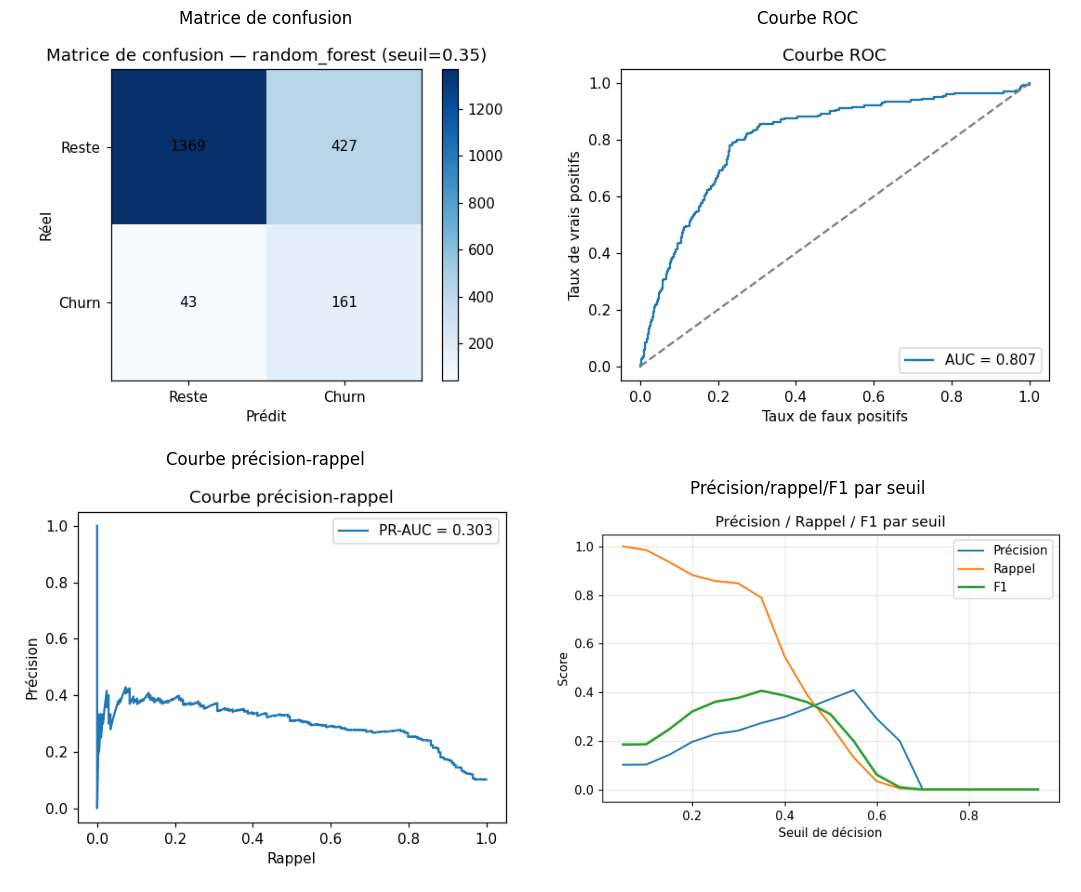

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, p, title in [
    (axes[0,0], '../reports/figures/confusion_matrix_final.png', 'Matrice de confusion'),
    (axes[0,1], '../reports/figures/roc_curve_final.png', 'Courbe ROC'),
    (axes[1,0], '../reports/figures/pr_curve_final.png', 'Courbe précision-rappel'),
    (axes[1,1], '../reports/figures/threshold_analysis.png', 'Précision/rappel/F1 par seuil'),
]:
    img = plt.imread(p)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
fig.tight_layout()
plt.show()

## 6. Décision et compromis

Le Random Forest est retenu comme modèle candidat final. Il offre :
- Un F1 légèrement supérieur (0,407 contre 0,384 pour XGBoost) ;
- Un Recall très élevé (0,789) qui dépasse la cible PRD (0,65) ;
- Une stabilité en cross-validation supérieure à XGBoost ;
- Une interprétabilité native (feature_importances_ + compatibilité SHAP TreeExplainer).

Le PR-AUC plafonne à 0,30 quel que soit le modèle ou la stratégie de déséquilibre — le dataset présente un plafond de signal autour de cette valeur après trois itérations d'optimisation distinctes.